In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

breast_cancer = load_breast_cancer()

data = breast_cancer.data
features = breast_cancer.feature_names
target = breast_cancer.target

df = pd.DataFrame(data=data, columns=features)
df['target'] = target

print(df.head())
print(df.info())
print(df['target'].unique())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [2]:
from sklearn.model_selection import train_test_split

features = df.drop(columns=['target'])

x_train, x_test, y_train, y_test = train_test_split(features, df['target'], test_size=0.3, random_state=42)

In [3]:
import os 

n_jobs = round(os.cpu_count() / 2)

In [4]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, recall_score

# Per score su classe 0 e non 1
scorer = make_scorer(recall_score, pos_label=0)

# IMPORTANTE! Ratio per il modello
ratio = (y_train == 0).sum() / (y_train == 1).sum()
# il ratio su xgboost tiene in considerazione la classe positiva, in questo modo andiamo a dare più peso su un errore nella classe negativa (0/1)

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True), 
        'max_depth': trial.suggest_int('max_depth', 3, 15), 
        'n_estimators': trial.suggest_int('n_estimators', 100, 1500), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), 
        'gamma': trial.suggest_float('gamma', 0.0, 5.0), 
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)  
    }

    model = XGBClassifier(**params, scale_pos_weight = ratio, random_state=42, n_jobs=n_jobs)
    return cross_val_score(model, x_train, y_train, cv=5, scoring=scorer).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best CV R²:  {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

/home/dave/git/CodeAcademy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 43. Best value: 0.972874: 100%|██████████| 50/50 [00:50<00:00,  1.02s/it]

Best CV R²:  0.9729
Best params: {'learning_rate': 0.05829269464713253, 'max_depth': 8, 'n_estimators': 725, 'subsample': 0.6377745299236594, 'colsample_bytree': 0.6970162755096405, 'min_child_weight': 5, 'gamma': 2.0265593931114596, 'reg_alpha': 0.0013162766604248438, 'reg_lambda': 9.53806295322323e-06}


In [5]:
from sklearn.metrics import f1_score, recall_score, precision_score

best_model = XGBClassifier(**study.best_params, random_state=42, n_jobs=n_jobs)
best_model.fit(x_train, y_train)

print(f'F1:{f1_score(y_test, best_model.predict(x_test), pos_label=0):.1%}')
print(f'Recall:{recall_score(y_test, best_model.predict(x_test), pos_label=0):.1%}')
print(f'Precision:{precision_score(y_test, best_model.predict(x_test), pos_label=0):.1%}')

F1:97.6%
Recall:96.8%
Precision:98.4%


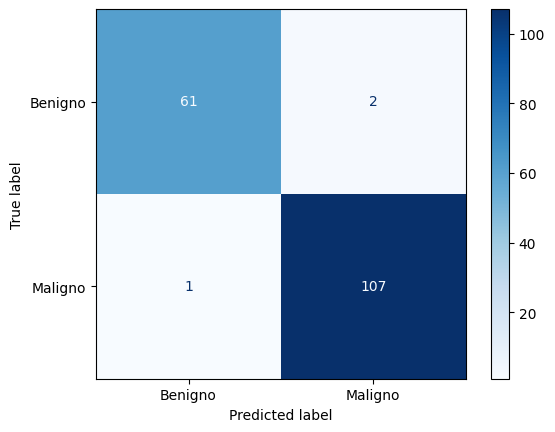

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(best_model, x_test, y_test, display_labels=['Benigno', 'Maligno'], cmap='Blues')
plt.show()
plt.close()

Text(0.5, 0, 'Importanza relativa')

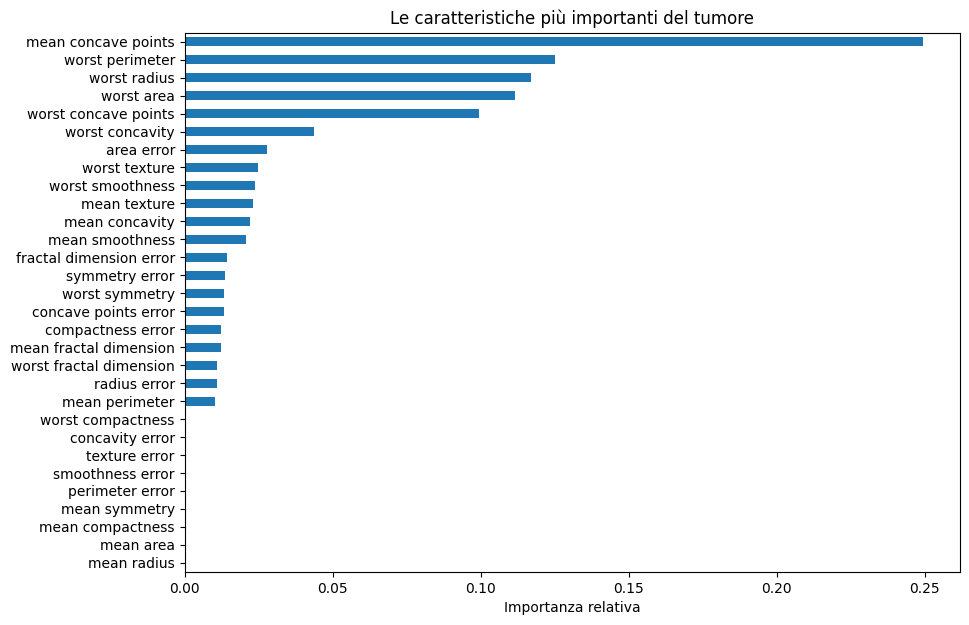

In [7]:
features = breast_cancer.feature_names
importances = best_model.feature_importances_

feat_imp = pd.Series(importances, features).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh')
plt.title("Le caratteristiche più importanti del tumore")
plt.xlabel("Importanza relativa")